# Document Layout Detection: YOLO vs RT-DETR

## Data Preparation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
! pip install ultralytics

### Validate Data Extraction

In [ ]:
import json
from collections import Counter

splits = ["train", "val", "test"]

for split in splits:
    json_path = f".data/labels_coco_multi_cat/labels_coco_{split}.json"
    
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    categories = [img.get("doc_category") for img in data["images"]]
    
    dist = Counter(categories)
    
    print(f"\nDistribution in {split.upper()}-Split:")
    for cat, count in dist.items():
        print(f"  - {cat}: {count} Images")


Verteilung im TRAIN-Split:
  - scientific_articles: 3000 Bilder
  - laws_and_regulations: 3000 Bilder
  - financial_reports: 3000 Bilder

Verteilung im VAL-Split:
  - laws_and_regulations: 944 Bilder
  - financial_reports: 944 Bilder
  - scientific_articles: 944 Bilder

Verteilung im TEST-Split:
  - laws_and_regulations: 784 Bilder
  - financial_reports: 784 Bilder
  - scientific_articles: 784 Bilder


In [ ]:
import json

splits = ["train", "val", "test"]

for split in splits:
    json_path = f".data/labels_coco_multi_cat/labels_coco_{split}.json"
    
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    annotated_image_ids = {ann['image_id'] for ann in data['annotations']}
    
    total_images = len(data['images'])
    empty_images_count = 0
    empty_per_cat = {}
    
    for img in data['images']:
        img_id = img['id']
        cat = img.get("doc_category")
        
        if img_id not in annotated_image_ids:
            empty_images_count += 1
            empty_per_cat[cat] = empty_per_cat.get(cat, 0) + 1
            
    print(f"\n--- Background Analysis for {split.upper()} ---")
    print(f"Total images in subset: {total_images}")
    print(f"Of which are pure background images (without boxes): {empty_images_count} ({empty_images_count/total_images*100:.1f}%)")
    if empty_images_count > 0:
        print(f"Empty pages per category: {empty_per_cat}")


--- Hintergrund-Analyse für TRAIN ---
Gesamt-Bilder im Subset: 9000
Davon reine Hintergrund-Bilder (ohne Boxen): 47 (0.5%)
Leere Seiten pro Kategorie: {'financial_reports': 13, 'laws_and_regulations': 34}

--- Hintergrund-Analyse für VAL ---
Gesamt-Bilder im Subset: 2832
Davon reine Hintergrund-Bilder (ohne Boxen): 8 (0.3%)
Leere Seiten pro Kategorie: {'financial_reports': 5, 'laws_and_regulations': 2, 'scientific_articles': 1}

--- Hintergrund-Analyse für TEST ---
Gesamt-Bilder im Subset: 2352
Davon reine Hintergrund-Bilder (ohne Boxen): 2 (0.1%)
Leere Seiten pro Kategorie: {'laws_and_regulations': 1, 'financial_reports': 1}


In [1]:
# printing length of folder .data/images/train
import os
num_train_images = len(os.listdir(".data/images/train"))
print(f"Number of training images: {num_train_images}")

Number of training images: 5000


In [4]:
import os
# printing length of folder .data/images/val
num_val_images = len(os.listdir(".data/images/test"))
print(f"Number of validation images: {num_val_images}")

Number of validation images: 943


Prüfe Bild-ID: d3fc6ebab0d8048547b0d23fa3289d973e27556ecfb7f2a43aa7d5bf6c2ca2a9.png (ID: 33884)
Dokumenten-Kategorie: scientific_articles
-> Bilddatei physisch vorhanden. Überprüfe Bounding Boxen...
-> 25 Bounding Boxen im JSON für dieses Bild gefunden.


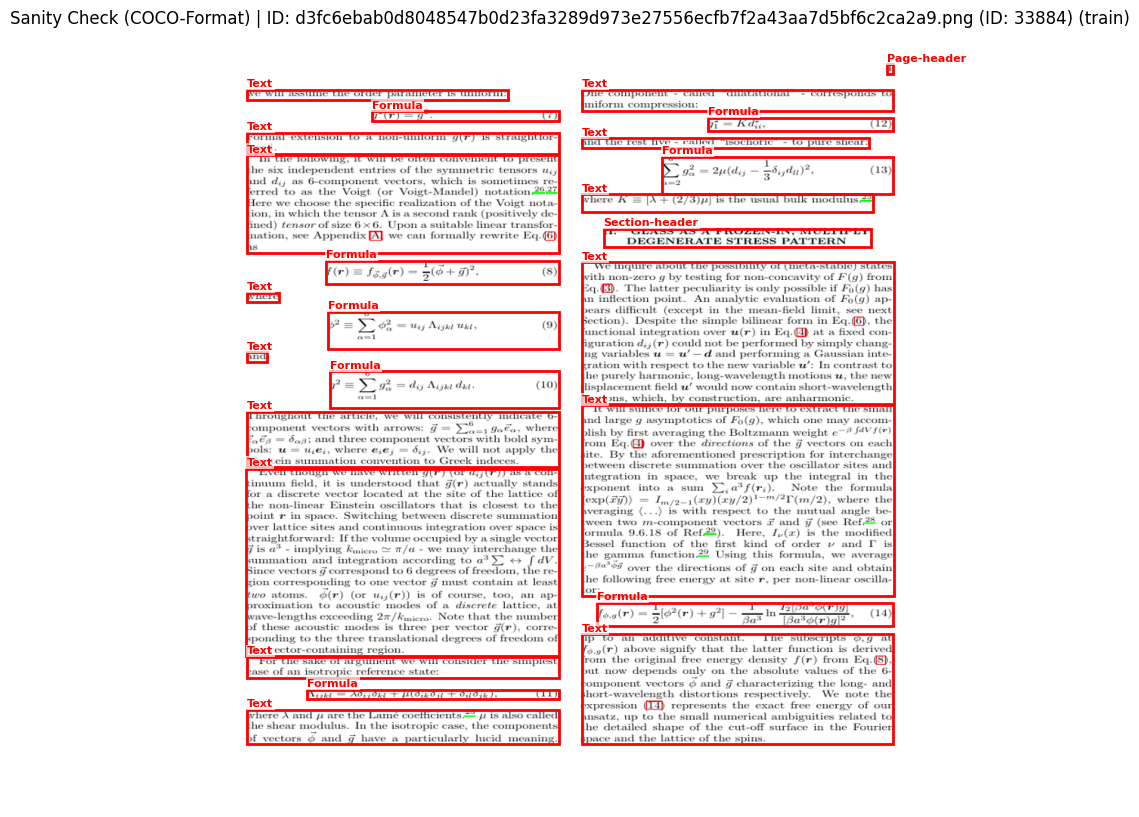

In [ ]:
import json
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

SUBSET_DIR = ".data"
SPLIT = "train"

JSON_PATH = f"{SUBSET_DIR}/labels_coco/labels_coco_{SPLIT}.json"
IMAGES_DIR = f"{SUBSET_DIR}/images/{SPLIT}"

with open(JSON_PATH, 'r') as f:
    coco_data = json.load(f)

cat_id_to_name = {c['id']: c['name'] for c in coco_data['categories']}

random_img_info = random.choice(coco_data['images'])
img_file_name = random_img_info['file_name']
img_path = os.path.join(IMAGES_DIR, img_file_name)

print(f"Checking image: {img_file_name} (ID: {random_img_info['id']})")
print(f"Document category: {random_img_info.get('doc_category')}")

if not os.path.exists(img_path):
    print(f"ERROR: Image file {img_file_name} was not found in folder {IMAGES_DIR}!")
    exit()
else:
    print("-> Image file physically present. Checking bounding boxes...")

img_annotations = [ann for ann in coco_data['annotations'] if ann['image_id'] == random_img_info['id']]
print(f"-> {len(img_annotations)} bounding boxes found in JSON for this image.")

img = Image.open(img_path)
fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(img)

for ann in img_annotations:
    x, y, w, h = ann['bbox']
    cat_name = cat_id_to_name[ann['category_id']]
    
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    
    plt.text(x, y - 4, cat_name, color='red', fontsize=8, weight='bold', 
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

plt.title(f"Sanity Check (COCO-Format) | ID: {img_file_name} (ID: {random_img_info['id']}) ({SPLIT})")
plt.axis('off')

plt.show()

### Convert COCO to YOLO Format

In [13]:
from ultralytics.data.converter import convert_coco

convert_coco(
    labels_dir=".data/labels_coco/",
    save_dir=".data/converted",
    cls91to80=False,
)

Annotations /home/rapha/projects/doclayout-det/.data/labels_coco/labels_coco_test.json: 100% ━━━━━━━━━━━━ 943/943 4.2Kit/s 0.2s0.0s
Annotations /home/rapha/projects/doclayout-det/.data/labels_coco/labels_coco_train.json: 100% ━━━━━━━━━━━━ 4999/4999 4.4Kit/s 1.1s0.0s
Annotations /home/rapha/projects/doclayout-det/.data/labels_coco/labels_coco_val.json: 100% ━━━━━━━━━━━━ 943/943 5.1Kit/s 0.2s0.2s
COCO data converted successfully.
Results saved to /home/rapha/projects/doclayout-det/.data/converted


In [14]:
import shutil
from pathlib import Path

# Paths
converted_dir = Path(".data/converted/")
dataset_dir = Path(".data")

# Move labels next to images for each split
for split, new_folder_name in [("labels_coco_train", "labels_train"), ("labels_coco_val", "labels_val"), ("labels_coco_test", "labels_test")]:
    src = converted_dir / "labels" / split
    print(src)
    dst = dataset_dir / "labels" / new_folder_name
    dst.mkdir(parents=True, exist_ok=True)
    for f in src.glob("*.txt"):
        shutil.move(str(f), str(dst / f.name))

# delete the converted directory after moving the labels
if converted_dir.exists():
    shutil.rmtree(converted_dir)

.data/converted/labels/labels_coco_train
.data/converted/labels/labels_coco_val
.data/converted/labels/labels_coco_test


In [ ]:
import json
from pathlib import Path

import yaml

# Read categories from your COCO JSON
with open(".data/labels_coco/labels_coco_train.json") as f:
    coco = json.load(f)

# Build class names matching convert_coco output (category_id - 1)
categories = sorted(coco["categories"], key=lambda x: x["id"])
names = {cat["id"] - 1: cat["name"] for cat in categories}

# Create dataset.yaml
dataset = {
    "path": str(Path(".data").resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": names,
}

with open(".data/dataset.yaml", "w") as f:
    yaml.dump(dataset, f, default_flow_style=False)

## Training YOLO

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

results = model.train(
    data=".data/dataset.yaml", 
    epochs=10, 
    imgsz=640,
    batch=16,     
    workers=1,
    amp=True,
    cache=False,
    device=0
)

Ultralytics 8.4.56 🚀 Python-3.12.3 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=.data/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

In [24]:
print("\n--- TESTRUN EVALUATION METRICS ---")
print(f"mAP50:    {results.results_dict['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95: {results.results_dict['metrics/mAP50-95(B)']:.4f}")


--- TESTRUN EVALUATION METRICS ---
mAP50:    0.7619
mAP50-95: 0.6102


## Training RT-DETR

dependencies:
- onnx
- onnxruntime
- tensorrt-cu13==11.0.0.114
 + tensorrt-cu13-bindings==11.0.0.114
 + tensorrt-cu13-libs==11.0.0.114

In [ ]:
from ultralytics import RTDETR

rtdetr = RTDETR("rtdetr-l.pt")

results = rtdetr.train(
    data=".data/dataset.yaml",
    epochs=1,
    imgsz=320,
    batch=2,
    workers=1,
    project="doclaynet_vergleich",
    name="rt_detr_l"
)

## Evaluation

In [ ]:
from ultralytics import YOLO, RTDETR
import os

YOLO_WEIGHTS = "/content/drive/MyDrive/doclayout-det/yolo26l/weights/best.pt"
RTDETR_WEIGHTS = "/content/drive/MyDrive/doclayout-det/rt_detr_l-4/weights/best.pt"

def evaluate_model(model_path, model_type="YOLO"):
    print(f" Starting Evaluation for {model_type} ({model_path})")

    if not os.path.exists(model_path):
        print(f"Error: Weights not found for {model_path}!")
        return

    if model_type == "YOLO":
        model = YOLO(model_path)
    elif model_type == "RT-DETR":
        model = RTDETR(model_path)

    metrics = model.val(
        data="/content/.data/dataset.yaml",
        split="test",
        imgsz=640,
        batch=16,
        workers=0,
        device=0,
        plots=True,
        save_txt=True,
        save_conf=True
    )

    print(f"\n--- Evaluation {model_type} ---")
    print(f"mAP@50: {metrics.box.map50:.4f}")
    print(f"mAP@50-95: {metrics.box.map:.4f}")
    print(f"Precision: {metrics.box.mp:.4f}")
    print(f"Recall: {metrics.box.mr:.4f}")

    print(f"\n--- Speed-Metrics ---")
    print(f"Pre-process: {metrics.speed['preprocess']:.2f} ms")
    print(f"Inference: {metrics.speed['inference']:.2f} ms")
    print(f"Post-process: {metrics.speed['postprocess']:.2f} ms")

    return metrics

yolo_metrics = evaluate_model(YOLO_WEIGHTS, model_type="YOLO")
rt_detr_metrics = evaluate_model(RTDETR_WEIGHTS, model_type="RT-DETR")